# Installs

In [3]:
!python --version
!pip --version

Python 3.11.9
pip 26.1.2 from C:\Users\pesen\Documents\UCL Masters Coursework\Masters Project SWOT\swot_env\Lib\site-packages\pip (python 3.11)



In [9]:
!pip install xarray netCDF4 matplotlib

  Using cached packaging-26.2-py3-none-any.whl.metadata (3.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 1.4/1.4 MB 14.8 MB/s  0:00:00
   ---------------------------------------- 0.0/21.3 MB ? eta -:--:--
   ------------------------------- -------- 16.5/21.3 MB 80.1 MB/s eta 0:00:01
   ---------------------------------------- 21.3/21.3 MB 67.2 MB/s  0:00:00
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ---------------------------------------- 9.3/9.3 MB 72.4 MB/s  0:00:00
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/2.4 MB ? eta -:--:--
   ---------------------------------------- 2.4/2.4 MB 67.6 MB/s  0:00:00
Using cached packaging-26.2-py3-none-any.whl (100 kB)
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   --------------------------------------

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
podaac-data-subscriber 1.15.2 requires packaging<24.0,>=23.0, but you have packaging 26.2 which is incompatible.


# Imports

In [2]:
import xarray as xr
import matplotlib.pyplot as plt

# Data Download

In [8]:
!podaac-data-downloader -c SWOT_L2_LR_SSH_D -d ./data/test_data_18Jun -sd 2024-01-01T00:00:00Z -ed 2024-01-02T00:00:00Z --limit 5

[2026-06-18 22:16:59,323] {podaac_data_downloader.py:146} INFO - NOTE: Making new data directory at ./data/test_data_18Jun(This is the first run.)
[2026-06-18 22:17:01,430] {podaac_data_downloader.py:317} INFO - Found 116 total files to download
[2026-06-18 22:17:01,430] {podaac_data_downloader.py:319} INFO - Limiting downloads to 5 total files
[2026-06-18 22:17:07,218] {podaac_data_downloader.py:358} INFO - 2026-06-18 22:17:07.218609 SUCCESS: https://archive.swot.podaac.earthdata.nasa.gov/podaac-swot-ops-cumulus-protected/SWOT_L2_LR_SSH_D/SWOT_L2_LR_SSH_Basic_008_524_20240101T231609_20240102T000738_PGD0_02.nc
[2026-06-18 22:17:09,988] {podaac_data_downloader.py:358} INFO - 2026-06-18 22:17:09.987759 SUCCESS: https://archive.swot.podaac.earthdata.nasa.gov/podaac-swot-ops-cumulus-protected/SWOT_L2_LR_SSH_D/SWOT_L2_LR_SSH_WindWave_008_524_20240101T231609_20240102T000738_PGD0_02.nc
[2026-06-18 22:17:13,325] {podaac_data_downloader.py:358} INFO - 2026-06-18 22:17:13.325603 SUCCESS: https:/

<xarray.Dataset> Size: 112MB
Dimensions:                                (num_lines: 9866, num_pixels: 69,
                                            num_sides: 2)
Coordinates:
    latitude                               (num_lines, num_pixels) float64 5MB ...
    longitude                              (num_lines, num_pixels) float64 5MB ...
Dimensions without coordinates: num_lines, num_pixels, num_sides
Data variables: (12/24)
    time                                   (num_lines) datetime64[ns] 79kB ...
    time_tai                               (num_lines) datetime64[ns] 79kB ...
    ssh_karin                              (num_lines, num_pixels) float64 5MB ...
    ssh_karin_qual                         (num_lines, num_pixels) float64 5MB ...
    ssh_karin_uncert                       (num_lines, num_pixels) float64 5MB ...
    ssha_karin                             (num_lines, num_pixels) float64 5MB ...
    ...                                     ...
    mean_sea_surface_cnescls               (num_lines, num_pixels) float64 5MB ...
    mean_sea_surface_cnescls_uncert        (num_lines, num_pixels) float64 5MB ...
    geoid                                  (num_lines, num_pixels) float64 5MB ...
    internal_tide_hret                     (num_lines, num_pixels) float64 5MB ...
    height_cor_xover                       (num_lines, num_pixels) float64 5MB ...
    height_cor_xover_qual                  (num_lines, num_pixels) float32 3MB ...
Attributes: (12/62)
    Conventions:                                   CF-1.7
    title:                                         Level 2 Low Rate Sea Surfa...
    institution:                                   CNES
    source:                                        Ka-band radar interferometer
    history:                                       2025-08-25T12:01:51Z : Cre...
    platform:                                      SWOT
    ...                                            ...
    ellipsoid_semi_major_axis:                     6378137.0
    ellipsoid_flattening:                          0.0033528106647474805
    good_ocean_data_percent:                       69.07972209138012
    ssha_variance:                                 1.6621568650323055
    references:                                    V1.4.1
    equator_longitude:                             82.77

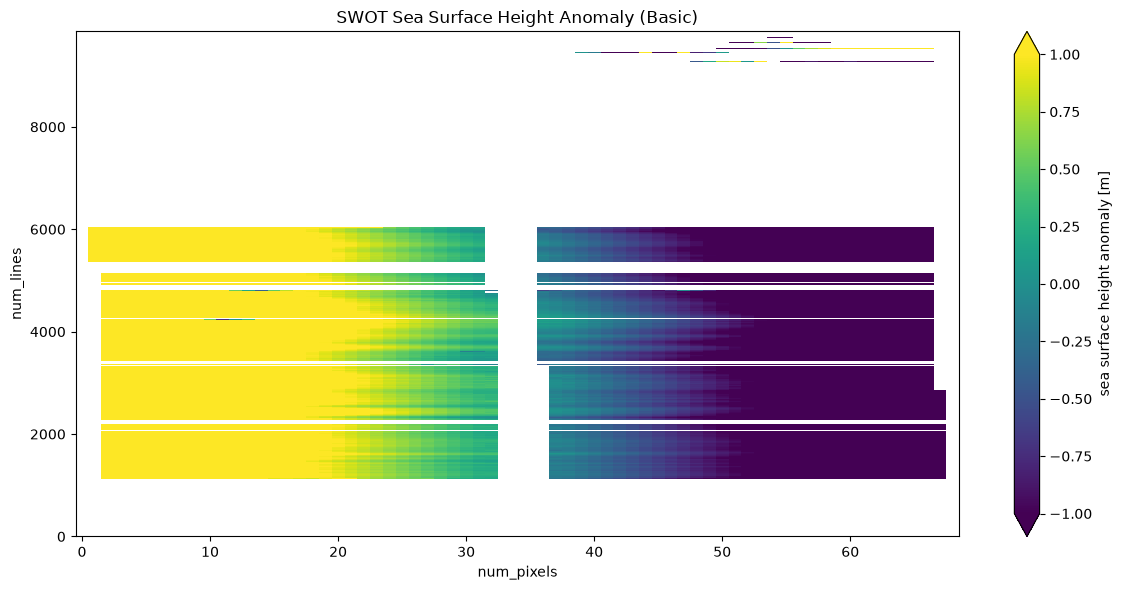

In [20]:
file_path = "./data/test_data_18Jun/SWOT_L2_LR_SSH_Basic_008_523_20240101T222542_20240101T231611_PGD0_02.nc"

ds = xr.open_dataset(file_path)

# Display Xarray dataframe
display(ds)

# Display SSHA
ds['ssha_karin'].plot(cmap='viridis', size=6, aspect=2, vmin=-1, vmax=1)
plt.title('SWOT Sea Surface Height Anomaly (Basic)')
plt.tight_layout()
plt.show()

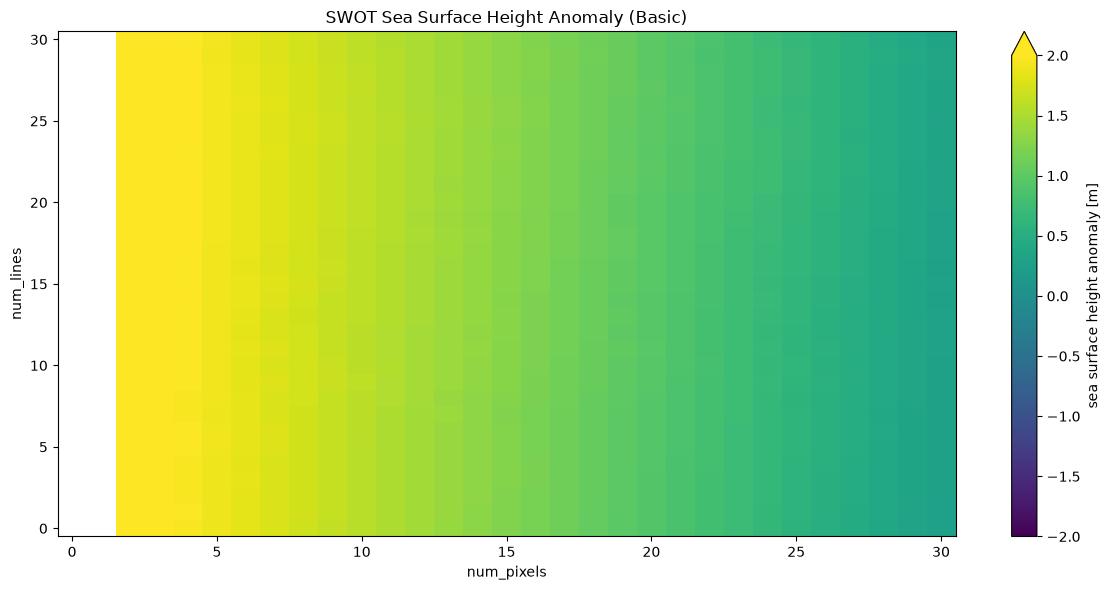

In [23]:
small_patch_ds = ds.isel(num_pixels=slice(0, 31), num_lines=slice(1500, 1531))

small_patch_ds['ssha_karin'].plot(cmap='viridis', size=6, aspect=2, vmin=-2, vmax=2)
plt.title('SWOT Sea Surface Height Anomaly (Basic)')
plt.tight_layout()
plt.show()